#### Building Model

Geosave engine gives you the flexibility to use custom model, but we will show you how to use our built in model

In [1]:
%load_ext autoreload
%autoreload 2

from geosave_engine.ml.models.contract import ContextChain
from geosave_engine.ml.models.encoder import DINOv3
from geosave_engine.ml.models.decoder import DPT
from geosave_engine.ml.models.head import DenseHead

# we will built sematnic segmentation model

encoder = DINOv3(
    model_name="vit_small_plus_patch16_dinov3_qkvb.lvd1689m",
    pretrained=False,
    in_channels=3,
    input_size=224
)

decoder = DPT(
    encoder_out_channels=encoder.out_channels,
    encoder_output_strides=encoder.output_strides,
)

head = DenseHead(
    decoder_out_channels=decoder.out_channels,
    num_classes=6,
    dropout=0.1,
)

model = ContextChain(
    encoder=encoder,
    decoder=decoder,
    head=head
)
model

2026-07-27 07:59:31,765 - WARNING - WARNING[XFORMERS]: xFormers can't load C++/CUDA extensions. xFormers was built for:
    PyTorch 2.10.0+cu128 with CUDA 1208 (you have 2.11.0+cu130)
    Python  3.10.19 (you have 3.12.10)
  Please reinstall xformers (see https://github.com/facebookresearch/xformers#installing-xformers)
  Memory-efficient attention, SwiGLU, sparse and more won't be available.
  Set XFORMERS_MORE_DETAILS=1 for more details


required_keys: image: Tensor

data flow:
  encoder: DINOv3.forward_pyramid(image: Tensor) -> {pyramid: list, prefix_tokens: list}
  decoder: DPT.forward_feature_map(pyramid: list, prefix_tokens: list) -> {feature_map: Tensor}
  head: DenseHead.forward_logits(feature_map: Tensor) -> Tensor

ContextChain(
  (encoder): DINOv3(
    (model): Eva(
      (patch_embed): PatchEmbed(
        (proj): Conv2d(3, 384, kernel_size=(16, 16), stride=(16, 16))
        (norm): Identity()
      )
      (pos_drop): Dropout(p=0.0, inplace=False)
      (rope): RotaryEmbeddingDinoV3()
      (norm_pre): Identity()
      (blocks): ModuleList(
        (0-11): 12 x EvaBlock(
          (norm1): LayerNorm((384,), eps=1e-05, elementwise_affine=True)
          (attn): EvaAttention(
            (qkv): Linear(in_features=384, out_features=1152, bias=False)
            (q_norm): Identity()
            (k_norm): Identity()
            (attn_drop): Dropout(p=0.0, inplace=False)
            (norm): Identity()
            (

In [2]:
from torchsummary import summary

input_size = (3, 224, 224)  # Example input size (channels, height, width)
summary(model, input_size=input_size, device="cpu")

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1          [-1, 384, 14, 14]         295,296
          Identity-2          [-1, 14, 14, 384]               0
        PatchEmbed-3          [-1, 14, 14, 384]               0
           Dropout-4             [-1, 201, 384]               0
          Identity-5             [-1, 201, 384]               0
         LayerNorm-6             [-1, 201, 384]             768
          Identity-7           [-1, 6, 201, 64]               0
          Identity-8           [-1, 6, 201, 64]               0
          Identity-9             [-1, 201, 384]               0
           Linear-10             [-1, 201, 384]         147,840
          Dropout-11             [-1, 201, 384]               0
     EvaAttention-12             [-1, 201, 384]               0
         Identity-13             [-1, 201, 384]               0
        LayerNorm-14             [-1, 2

#### Model Registry

You don't need to do manual import for each model, this would be useful for config based training

In [3]:
from geosave_engine.ml.registry import list_models

list_models()

{'decoder': ['DPT', 'UNET'],
 'encoder': ['CLAY', 'DINOV3', 'PRITHVI', 'PRITHVI_TL'],
 'head': ['DENSE'],
 'model': ['IBM_GRANITE_BIOMASS']}

In [4]:
from geosave_engine.ml.registry import build_model

# or you can use the registry to build the model from a config dictionary

stages = dict(
    encoder="dinov3",
    decoder="dpt",
    head="dense"
)

# Notice how we don't need to specify the encoder_out_channels and encoder_output_strides for the decoder
# as they will be automatically inferred from the encoder's output channels and output strides.
config = dict(
    encoder=dict(
        model_name="vit_small_plus_patch16_dinov3_qkvb.lvd1689m",
        pretrained=False,
        in_channels=3,
        input_size=224
    ),
    head=dict(
        num_classes=6,
        dropout=0.1
    )
)

model_from_registry = build_model(stages=stages, config=config)
model_from_registry

required_keys: image: Tensor

data flow:
  encoder: DINOv3.forward_pyramid(image: Tensor) -> {pyramid: list, prefix_tokens: list}
  decoder: DPT.forward_feature_map(pyramid: list, prefix_tokens: list) -> {feature_map: Tensor}
  head: DenseHead.forward_logits(feature_map: Tensor) -> Tensor

ContextChain(
  (encoder): DINOv3(
    (model): Eva(
      (patch_embed): PatchEmbed(
        (proj): Conv2d(3, 384, kernel_size=(16, 16), stride=(16, 16))
        (norm): Identity()
      )
      (pos_drop): Dropout(p=0.0, inplace=False)
      (rope): RotaryEmbeddingDinoV3()
      (norm_pre): Identity()
      (blocks): ModuleList(
        (0-11): 12 x EvaBlock(
          (norm1): LayerNorm((384,), eps=1e-05, elementwise_affine=True)
          (attn): EvaAttention(
            (qkv): Linear(in_features=384, out_features=1152, bias=False)
            (q_norm): Identity()
            (k_norm): Identity()
            (attn_drop): Dropout(p=0.0, inplace=False)
            (norm): Identity()
            (

In [5]:
import torch

input_tensor = torch.randn(1, 3, 224, 224)  # Batch size of 1, 3 channels (RGB), 224x224 image
output = model_from_registry(input_tensor)
output.shape  # Should be [1, 6, 224, 224] for 6 classes and same spatial dimensions

torch.Size([1, 6, 224, 224])

#### Custom model and what is ContextChain?

A custom model may contain several independent modules, such as an encoder, decoder, and prediction head. GeoSave uses ContextChain to connect these modules automatically.

Each module declares its inputs and outputs through a method decorated with @model_context:

In [6]:
import torch.nn as nn
from geosave_engine.ml.models.contract import model_context


class Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

    # image is required as input and features is produced as output. Typehints is necessary here
    @model_context()
    def encode(self, image: torch.Tensor) -> torch.Tensor:
        features = self.encoder(image) # 
        return features

class Decoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2),
            nn.ReLU(),
            nn.Conv2d(32, 16, kernel_size=3, padding=1),
            nn.ReLU()
        )

    @model_context()
    def decode(self, features: torch.Tensor) -> torch.Tensor:
        decoded = self.decoder(features)
        return decoded # the name of the return value is "decoded", which will be used as the key in the context dictionary

class Head(nn.Module):
    def __init__(self, num_classes: int):
        super().__init__()
        self.head = nn.Sequential(
            nn.Conv2d(16, num_classes, kernel_size=1)
        )

    @model_context(head=True) # means this is the last step in the model, and the output will be returned directly
    def predict(self, decoded: torch.Tensor) -> torch.Tensor:
        output = self.head(decoded)
        return output

model = ContextChain(
    encoder=Encoder(),
    decoder=Decoder(),
    head=Head(num_classes=6)
)
model

required_keys: image: Tensor

data flow:
  encoder: Encoder.encode(image: Tensor) -> {features: Tensor}
  decoder: Decoder.decode(features: Tensor) -> {decoded: Tensor}
  head: Head.predict(decoded: Tensor) -> Tensor

ContextChain(
  (encoder): Encoder(
    (encoder): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU()
      (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
  )
  (decoder): Decoder(
    (decoder): Sequential(
      (0): ConvTranspose2d(64, 32, kernel_size=(2, 2), stride=(2, 2))
      (1): ReLU()
      (2): Conv2d(32, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU()
    )
  )
  (head): Head(
    (head): Sequential(
      (0): Conv2d(16, 6, kernel_size=(1, 1), stride=(1, 1))
    )
  )
)

In [7]:
input_tensor = torch.randn(1, 3, 224, 224)  # Batch size of 1, 3 channels (RGB), 224x224 image
output = model(input_tensor)
output.shape  # Should be [1, 6, 224, 224] for 6 classes and same spatial dimensions

torch.Size([1, 6, 224, 224])

#### Monolith Model

There are also end to end model that we can't port to our modular design, we call it monolith, GraniteGeospatialBiomass model is one of the example. Basicaly prithvi backbone with UperNet decoder for predicting AGB

In [8]:
from geosave_engine.ml.models.monolith import GraniteGeospatialBiomass

# The input specification is provided on the docstring of the model, just hover over the model name to see the spec
# It rquires HLS bands of BLUE (B02), GREEN (B03), RED (B04), NIR_NARROW (B8A), SWIR_1 (B11), SWIR_2 (B12).
biomass_model = GraniteGeospatialBiomass(pretrained=False)

biomass_model

2026-07-27 08:41:39,731 - WARNING - WARNING[XFORMERS]: xFormers can't load C++/CUDA extensions. xFormers was built for:
    PyTorch 2.10.0+cu128 with CUDA 1208 (you have 2.11.0+cu130)
    Python  3.10.19 (you have 3.12.10)
  Please reinstall xformers (see https://github.com/facebookresearch/xformers#installing-xformers)
  Memory-efficient attention, SwiGLU, sparse and more won't be available.
  Set XFORMERS_MORE_DETAILS=1 for more details
/home/uwu/Projects/geosave-engine/.venv/lib/python3.12/site-packages/terratorch/models/prithvi_model_factory.py:76: UserWarning: PrithviModelFactory is deprecated. Please switch to EncoderDecoderFactory.
  warnings.warn("PrithviModelFactory is deprecated. Please switch to EncoderDecoderFactory.", stacklevel=1)


GraniteGeospatialBiomass(
  (model): PixelWiseModel(
    (encoder): TimmBackboneWrapper(
      (patch_embed): PatchEmbed(
        (drop): Dropout(p=0.0, inplace=False)
        (adap_padding): AdaptivePadding()
        (projection): Conv2d(6, 128, kernel_size=(4, 4), stride=(4, 4))
        (norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      )
      (stages_0): SwinBlockSequence(
        (blocks): ModuleList(
          (0): SwinBlock(
            (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
            (attn): ShiftWindowMSA(
              (w_msa): WindowMSA(
                (qkv): Linear(in_features=128, out_features=384, bias=True)
                (attn_drop): Dropout(p=0.0, inplace=False)
                (proj): Linear(in_features=128, out_features=128, bias=True)
                (proj_drop): Dropout(p=0.0, inplace=False)
                (softmax): Softmax(dim=-1)
              )
              (drop): DropPath(drop_prob=0.000)
            )
          

In [9]:
from geosave_engine.ml.transforms import ImageProcessor

preprocessor = ImageProcessor(model=biomass_model) # automatically apply mean and std normalization according to the model specs

#### Inference

Lets try to do inference with monolith model using the geosave engine library

In [1]:
from geosave_engine.geodata.stac import StacClient

# Does planetary computing microsoft client have the hls2-s30 collection?
client = StacClient.planetary_computer()
client.get_collections()

[<CollectionClient id=daymet-annual-pr>,
 <CollectionClient id=daymet-daily-hi>,
 <CollectionClient id=3dep-seamless>,
 <CollectionClient id=3dep-lidar-dsm>,
 <CollectionClient id=fia>,
 <CollectionClient id=gridmet>,
 <CollectionClient id=daymet-annual-na>,
 <CollectionClient id=daymet-monthly-na>,
 <CollectionClient id=daymet-annual-hi>,
 <CollectionClient id=daymet-monthly-hi>,
 <CollectionClient id=daymet-monthly-pr>,
 <CollectionClient id=gnatsgo-tables>,
 <CollectionClient id=hgb>,
 <CollectionClient id=cop-dem-glo-30>,
 <CollectionClient id=cop-dem-glo-90>,
 <CollectionClient id=terraclimate>,
 <CollectionClient id=nasa-nex-gddp-cmip6>,
 <CollectionClient id=gpm-imerg-hhr>,
 <CollectionClient id=gnatsgo-rasters>,
 <CollectionClient id=3dep-lidar-hag>,
 <CollectionClient id=io-lulc-annual-v02>,
 <CollectionClient id=goes-cmi>,
 <CollectionClient id=conus404>,
 <CollectionClient id=sentinel-1-rtc>,
 <CollectionClient id=3dep-lidar-intensity>,
 <CollectionClient id=3dep-lidar-point

In [2]:
# What are the bands of hls2-s30?
source = client.source("hls2-s30")

print("Bands metadata for hls2-s30:")
print(source.get_bands_metadata().keys())
print("Properties metadata for hls2-s30:")
source.get_metadata().get("properties")

Bands metadata for hls2-s30:
dict_keys(['B01', 'B02', 'B03', 'B04', 'B05', 'B06', 'B07', 'B08', 'B09', 'B10', 'B11', 'B12', 'B8A', 'SAA', 'SZA', 'VAA', 'VZA', 'Fmask', 'thumbnail', 'tilejson', 'rendered_preview'])
Properties metadata for hls2-s30:


{'sci:doi': '10.5067/HLS/HLSS30.002',
 'datetime': '2026-06-16T23:59:54.422750Z',
 'platform': 'sentinel-2c',
 'proj:shape': [3660, 3660],
 'instruments': ['msi'],
 'end_datetime': '2026-06-16T23:59:54.422750Z',
 'view:azimuth': 101.43664817,
 'eo:cloud_cover': 66.0,
 'proj:transform': [30.0,
  0.0,
  600000.0,
  0.0,
  -30.0,
  -1200000.0,
  0.0,
  0.0,
  1.0],
 'start_datetime': '2026-06-16T23:59:54.422750Z',
 'view:sun_azimuth': 35.6093607,
 'proj:code': 'EPSG:32656'}

In [3]:
BANDS = ["B02", "B03", "B04", "B8A", "B11", "B12"] # select accroding to specification of the model
source = client.source(
    "hls2-s30", 
    bands=BANDS,
    temporal_granularity="scene",
)
source.set_filter("eo:cloud_cover < 5", inplace=True)  # Filter for scenes with less than 5% cloud cover

In [4]:
from geosave_engine.geodata.tile import GeoAnchor, GeoStack

lat, lon  = -7.0490, 110.4380  # Center coordinate (latitude, longitude) for UNDIP
size_m = 5000 # Produce 5km tile
resolution_m = 10 # Each pixel represents 10 m
datetime = "2026-06" # Will be interpreted as 2026-06-01T00:00:00Z to 2026-06-30T23:59:59Z

anchor = GeoAnchor.from_coordinate(lat, lon, size_m=size_m, resolution=resolution_m, datetime=datetime)
ingest_iter = source.load(anchor)

tiles = []
for tile in ingest_iter:
    tile = tile.with_plot_meta(rgb_bands=("B04", "B03", "B02"))
    tiles.append(tile)

[########################################] | 100% Completed | 2.81 sms
[########################################] | 100% Completed | 3.14 sms
[########################################] | 100% Completed | 2.63 sms


Area of the tile: 25000000.0 m2


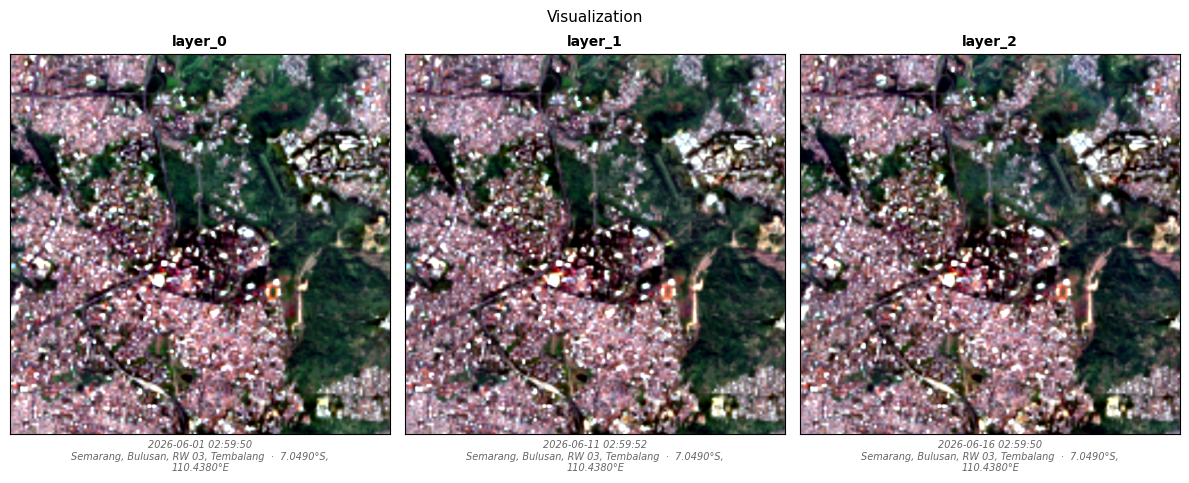

In [5]:
# Visualization of the tiles
stack = GeoStack(*tiles)

stack.plot(title="Visualization", cols=3)
print("Area of the tile:", anchor.area_m2, "m2")

In [6]:
import torch

input_tensor = torch.stack([tile.to_tensor() for tile in tiles])  # Stack the tiles into a batch tensor
input_tensor.shape  # Should be [N, T, 6, H, W]

torch.Size([3, 1, 6, 500, 500])

In [ ]:
input_tensor = input_tensor.squeeze(1)  # Remove the temporal dimension if it's 1, resulting in shape [N, 6, H, W]
input_tensor = preprocessor(input_tensor)  # Apply preprocessing (normalization) according to the model specs
output = biomass_model(input_tensor)  # Forward pass through the model
output.shape  # Should be [N, H, W] for biomass prediction

torch.Size([3, 500, 500])

#### Convert tensor to GeoTile

Tensor doesn't have geospatial metadata, so we will rebuild the GeoTile with the result as the data. We also can save the prediction to GeoTiff or zarr files

In [11]:
pred_tiles = []
for tile, pred in zip(tiles, output):
    pred_np = pred.detach().cpu().numpy()  # Convert the prediction tensor to a NumPy array
    pred_tile = tile.with_np(pred_np, names=["biomass"])  # Add a new band for biomass prediction
    pred_tiles.append(pred_tile)

(<Figure size 1200x460 with 6 Axes>,
 array([[<Axes: title={'center': 'layer_0'}, xlabel='2026-06-01 02:59:50\nSemarang, Bulusan, RW 03, Tembalang  ·  7.0490°S,\n110.4380°E'>,
         <Axes: title={'center': 'layer_1'}, xlabel='2026-06-11 02:59:52\nSemarang, Bulusan, RW 03, Tembalang  ·  7.0490°S,\n110.4380°E'>,
         <Axes: title={'center': 'layer_2'}, xlabel='2026-06-16 02:59:50\nSemarang, Bulusan, RW 03, Tembalang  ·  7.0490°S,\n110.4380°E'>]],
       dtype=object))

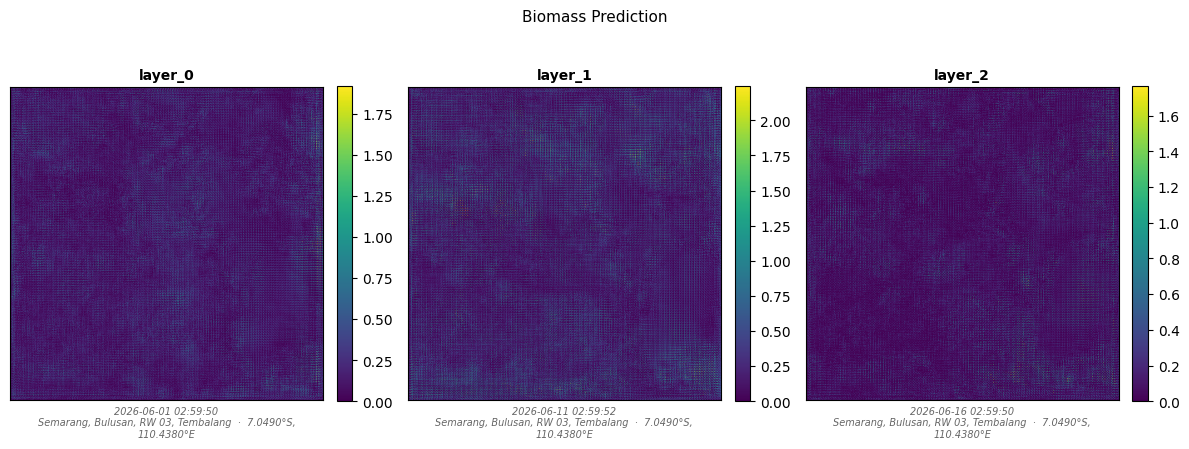

In [12]:
GeoStack(*pred_tiles).plot(title="Biomass Prediction", cols=3)

In [15]:
pixel_area_ha = tile.resolution ** 2 / 10000  # 10m × 10m = 100 m² = 0.01 ha

for i, tile in enumerate(pred_tiles):
    total_biomass_mg = float(tile.data.sum(skipna=True)) * pixel_area_ha
    print(f"layer_{i} biomass: {total_biomass_mg:.2f} Mg")

layer_0 biomass: 398.18 Mg
layer_1 biomass: 608.83 Mg
layer_2 biomass: 275.32 Mg
